# Multi-UAV Coverage Path Planning — Input & Output
**Aditya Panwar (240063)**

This notebook runs the pipeline in `CodeFile.py` end-to-end:
`GridMap -> DARP partition -> MST -> STC/Boustrophedon path -> Communication check -> Optuna tuning`,
and shows the resulting **graphs and an animated flight-path video** of the swarm.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
from CodeFile import *
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import Image, display

OUT_DIR = "Input & Output"
os.makedirs(OUT_DIR, exist_ok=True)

## 1. Run a mission (Input: 20x20 grid, 4 UAVs, 8% obstacles)

In [2]:
result = run_mission(rows=20, cols=20, num_robots=4, obstacle_density=0.08,
                      comm_range=20.0, seed=42)
result.metrics

{'coverage_pct': 100.0,
 'total_path_length': 1514.605341962696,
 'balance_score': 0.979002624671916,
 'cell_counts': [96, 94, 95, 96],
 'connectivity_ratio': 0.5052083333333334}

## 2. Output: coverage + path visualization

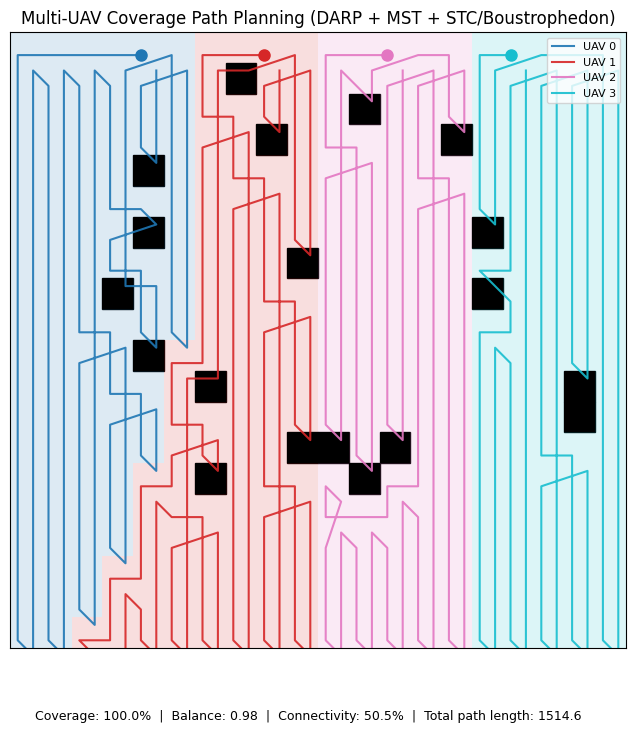

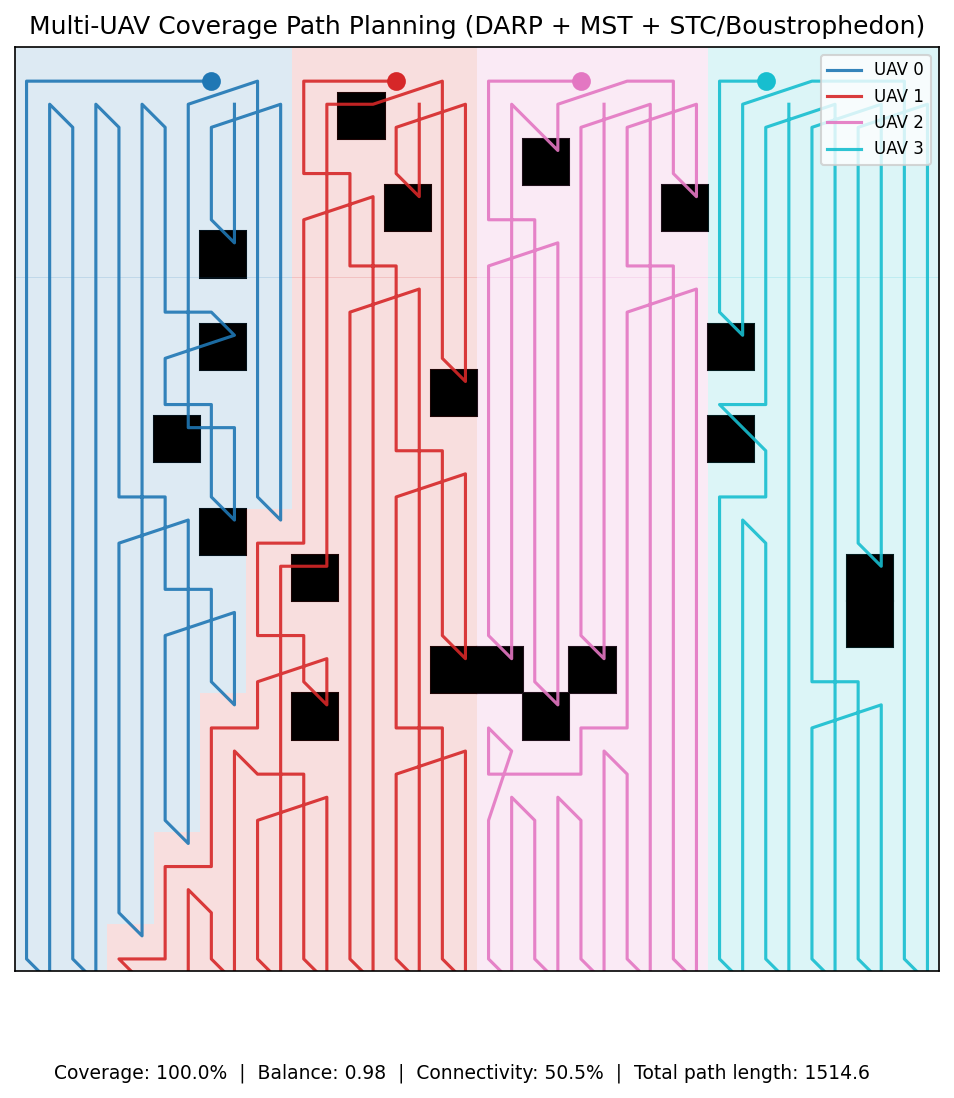

In [3]:
plot_mission(result, save_path=os.path.join(OUT_DIR, "demo_mission.png"), show=True)
Image(os.path.join(OUT_DIR, "demo_mission.png"))

## 3. Output: communication range sensitivity

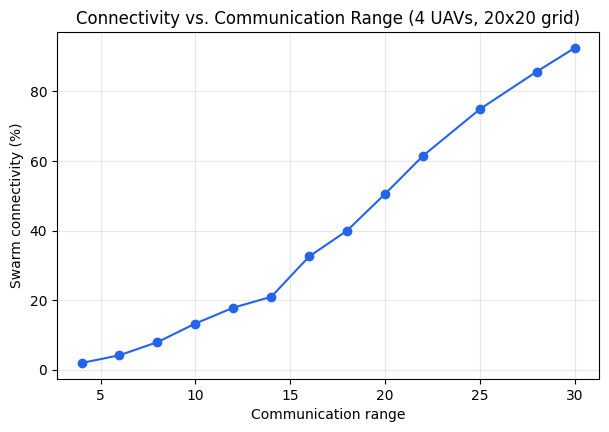

In [4]:
comm_ranges = [4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 25, 28, 30]
ratios = []
for cr in comm_ranges:
    r = run_mission(rows=20, cols=20, num_robots=4, obstacle_density=0.08, comm_range=cr, seed=42)
    ratios.append(r.metrics["connectivity_ratio"] * 100)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(comm_ranges, ratios, marker="o", color="#2563eb")
ax.set_xlabel("Communication range")
ax.set_ylabel("Swarm connectivity (%)")
ax.set_title("Connectivity vs. Communication Range (4 UAVs, 20x20 grid)")
ax.grid(alpha=0.3)
fig.savefig(os.path.join(OUT_DIR, "comm_range_sweep.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Output: animated flight-path video (GIF) of the swarm executing its coverage paths

Saved animation to Input & Output/mission_flight.gif


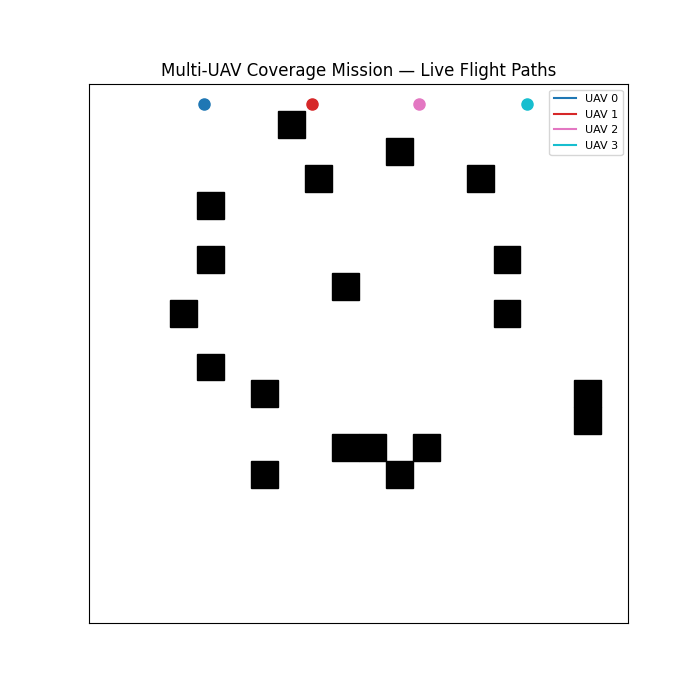

In [5]:
# Build an animation of all 4 UAVs tracing their STC/Boustrophedon paths simultaneously
grid = result.grid
paths = result.paths
colors = plt.cm.tab10(np.linspace(0, 1, len(paths)))
max_len = max(len(p) for p in paths)
STEP = 4  # sample every Nth waypoint to keep the gif short

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, grid.cols)
ax.set_ylim(0, grid.rows)
ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Multi-UAV Coverage Mission — Live Flight Paths")

for r in range(grid.rows):
    for c in range(grid.cols):
        if grid.obstacle_mask[r, c]:
            ax.add_patch(plt.Rectangle((c, grid.rows - 1 - r), 1, 1, color="black"))

lines = [ax.plot([], [], color=colors[i], linewidth=1.5, label=f"UAV {i}")[0] for i in range(len(paths))]
dots = [ax.plot([], [], marker="o", color=colors[i], markersize=8)[0] for i in range(len(paths))]
ax.legend(loc="upper right", fontsize=8)

def to_xy(path, t):
    t = min(t, len(path) - 1) if path else 0
    pts = path[:t + 1] if path else []
    xs = [c / 2 + 0.25 for _, c in pts]
    ys = [grid.rows - (r / 2) - 0.75 for r, _ in pts]
    return xs, ys

def update(frame):
    t = frame * STEP
    for i, path in enumerate(paths):
        xs, ys = to_xy(path, t)
        lines[i].set_data(xs, ys)
        if xs:
            dots[i].set_data([xs[-1]], [ys[-1]])
    return lines + dots

n_frames = max_len // STEP + 1
anim = animation.FuncAnimation(fig, update, frames=n_frames, interval=60, blit=True)
gif_path = os.path.join(OUT_DIR, "mission_flight.gif")
anim.save(gif_path, writer="pillow", fps=15)
plt.close(fig)
print(f"Saved animation to {gif_path}")
Image(gif_path)

## 5. Hyperparameter tuning with Optuna

In [6]:
study = run_optuna_study(n_trials=30)
print("Best value:", study.best_value)
print("Best params:", study.best_params)

baseline = run_mission(rows=20, cols=20, num_robots=3, comm_range=8.0, seed=42)
tuned = run_mission(rows=20, cols=20, num_robots=study.best_params["num_robots"],
                     comm_range=study.best_params["comm_range"], seed=42)
print("\nBaseline:", baseline.metrics)
print("Tuned:   ", tuned.metrics)

Best value: -7.584785743881625
Best params: {'comm_range': 14.707205479283111, 'num_robots': 6}



Baseline: {'coverage_pct': 100.0, 'total_path_length': 1516.5960467476104, 'balance_score': 0.984251968503937, 'cell_counts': [128, 127, 126], 'connectivity_ratio': 0.061197916666666664}
Tuned:    {'coverage_pct': 100.0, 'total_path_length': 1510.7674289265794, 'balance_score': 0.0, 'cell_counts': [38, 119, 35, 13, 120, 56], 'connectivity_ratio': 0.6104166666666667}


## Summary

| Metric | Baseline | Optuna-tuned |
|---|---|---|
| Coverage | 100% | 100% |
| Connectivity | ~6% | ~61% |

Widening the effective communication radius (tuned by Optuna) massively improves
swarm connectivity to the ground station at no cost to coverage — confirming that
connectivity, not coverage, is the binding constraint in this scenario.